# Automated ML Pipeline — Generic, Data-Driven
## From Raw CSV → EDA → Feature Engineering → Model Training → Hyperparameter Tuning

This notebook implements a **fully automated, adaptive machine learning pipeline** that:
- Works on **any CSV dataset** regardless of domain
- Makes intelligent decisions at every stage based on data characteristics
- Provides **verbose debug explanations** for every decision via print statements
- Generates **plots, JSON artifacts, and explanations** at each step
- Handles outliers through **smoothing only** (never removal)
- Automatically selects, trains, and tunes the best models

### How to use:
1. Set your CSV file path in the **Configuration** cell
2. Run the **Data Loading** cell
3. Review the column list and set your **TARGET** column
4. Run all remaining cells — the pipeline handles everything automatically

### Pipeline Stages:
| # | Stage | What Happens |
|---|-------|-------------|
| 1 | Configuration | Set file path, seed, output directory |
| 2 | Data Loading | Load CSV, preview, dtype summary |
| 3 | Column Overview | Print all columns for you to review |
| 4 | Target Selection | YOU set the target column here |
| 5 | Data Profiling | Nulls, duplicates, constants, ID-like, cardinality |
| 6 | Auto-Clean | Drop bad columns, impute remaining nulls |
| 7 | Target Analysis | Class balance, distribution, strategy decision |
| 8 | Outlier Handling | Detect & smooth outliers (no removal!) |
| 9 | Feature Type Handling | Encode categoricals, handle booleans |
| 10 | EDA & Visualization | Distributions, correlations, statistical tests, plots |
| 11 | Feature Selection | RF importance + Mutual Info + Stat tests → consensus ranking |
| 12 | Preprocessing | Train/test split, scaling |
| 13 | Model Shortlisting | Dynamic model selection based on data properties |
| 14 | Model Training | Cross-validation, ranking all candidates |
| 15 | Top-K Selection | Pick top 2 performers |
| 16 | Hyperparameter Tuning | Optuna optimization on top 2 |
| 17 | Final Evaluation | Test set metrics, confusion matrix, plots |
| 18 | Save Artifacts | Model, scaler, encoder, metadata JSON |

## Step 0 — Import Libraries

In [1]:
# ============================================================
# STEP 0: IMPORT ALL REQUIRED LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import warnings
from collections import Counter, OrderedDict
from datetime import datetime

from scipy import stats
from scipy.stats import skew, kurtosis

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     KFold, cross_val_score)
from sklearn.preprocessing import (LabelEncoder, StandardScaler, RobustScaler,
                                   MinMaxScaler, PowerTransformer, OrdinalEncoder)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              ExtraTreesClassifier, RandomForestRegressor,
                              GradientBoostingRegressor, ExtraTreesRegressor)
from sklearn.linear_model import (LogisticRegression, Ridge, Lasso,
                                  LinearRegression)
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, mean_squared_error,
                             mean_absolute_error, r2_score)
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('=' * 70)
print('STEP 0: LIBRARY IMPORT')
print('=' * 70)
print('All libraries imported successfully!')

STEP 0: LIBRARY IMPORT
All libraries imported successfully!


c:\Users\vicky\OneDrive\Desktop\SCS-projects\Mindspace-voice-agent\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Configuration
Set your CSV file path, random seed, and output directory below.

In [20]:
# ============================================================
# CONFIGURATION — EDIT THESE VALUES
# ============================================================
FILE_PATH   = r'data\mental_health_synthetic_dataset_with_normal.csv'   # <-- Your CSV file
RANDOM_SEED = 42
OUTPUT_DIR  = 'pipeline_output'

# ============================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

# Central pipeline state — JSON artifacts from every stage
PIPELINE_STATE = {}

print('=' * 70)
print('STEP 1: CONFIGURATION')
print('=' * 70)
print(f'  File path  : {FILE_PATH}')
print(f'  Random seed: {RANDOM_SEED}')
print(f'  Output dir : {OUTPUT_DIR}/')
print('  Configuration set successfully!')

STEP 1: CONFIGURATION
  File path  : data\mental_health_synthetic_dataset_with_normal.csv
  Random seed: 42
  Output dir : pipeline_output/
  Configuration set successfully!


## Step 2 — Data Loading
Load the CSV file and inspect its basic properties.

In [21]:
print('=' * 70)
print('STEP 2: DATA LOADING')
print('=' * 70)

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f'File not found: {FILE_PATH}')

df_raw = pd.read_csv(FILE_PATH)
df = df_raw.copy()

print(f'\nData loaded successfully from: {FILE_PATH}')
print(f'  Rows   : {df.shape[0]:,}')
print(f'  Columns: {df.shape[1]}')
print(f'  Memory : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

print(f'\nData Types Summary:')
for dtype, count in df.dtypes.value_counts().items():
    print(f'  {dtype}: {count} columns')

print(f'\nFirst 5 rows:')
display(df.head())

PIPELINE_STATE['data_loading'] = {
    'rows': int(df.shape[0]),
    'cols': int(df.shape[1]),
    'dtypes': {str(k): int(v) for k, v in df.dtypes.value_counts().items()},
    'file': FILE_PATH
}
print(f'\nStep 2 complete.')

STEP 2: DATA LOADING

Data loaded successfully from: data\mental_health_synthetic_dataset_with_normal.csv
  Rows   : 50,000
  Columns: 66
  Memory : 32.20 MB

Data Types Summary:
  float64: 61 columns
  object: 3 columns
  int64: 2 columns

First 5 rows:


,profile,language,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,...,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,target
0,Anxiety,marathi,326,106,0.327224,0.029449,0.096709,0.022415,0.022497,0.046256,...,0.152362,1.558506,0.963762,0.973875,-1.044599,0.990256,-2.120762,0.299595,-0.030952,Anxiety
1,Normal,hindi,310,163,0.526694,0.038544,0.007189,0.002901,0.012849,0.008080,...,0.390203,-0.226435,0.657373,-2.401558,-0.378611,-0.438761,-0.915927,0.236808,0.485772,Normal
2,Phobia,english,257,155,0.600898,0.016471,0.027356,0.028057,0.019666,0.003328,...,-0.694345,0.072844,-0.863955,0.567883,-1.347251,0.546552,0.582067,-0.655856,-0.396242,Phobia
3,Bipolar_Mania,hindi,541,317,0.586935,0.037961,0.062862,0.022836,0.040154,0.049701,...,0.836483,-0.768509,-0.192800,-0.791898,-0.110046,0.426967,0.395415,-0.012742,-0.283863,Bipolar_Mania
4,Depression,english,262,162,0.618375,0.012319,0.080076,0.045821,0.065387,0.021260,...,-0.716500,0.101404,0.091508,0.728622,-0.135279,-0.351390,-0.121473,0.802623,-0.023638,Depression



Step 2 complete.


## Step 3 — Column Overview
Review **all columns** below. In the **next cell**, you will set which column is the target.

In [22]:
print('=' * 70)
print('STEP 3: COLUMN OVERVIEW')
print('=' * 70)

col_info = []
for i, col in enumerate(df.columns):
    dtype = str(df[col].dtype)
    nulls = int(df[col].isnull().sum())
    null_pct = round(nulls / len(df) * 100, 2)
    unique = int(df[col].nunique())
    sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    if isinstance(sample, str) and len(str(sample)) > 30:
        sample = str(sample)[:30] + '...'
    col_info.append({
        '#': i, 'Column': col, 'Type': dtype,
        'Nulls': nulls, 'Null%': null_pct,
        'Unique': unique, 'Sample': sample
    })

col_df = pd.DataFrame(col_info)
print(col_df.to_string(index=False))

print(f'\n>>> IMPORTANT: In the NEXT cell, set your TARGET column name.')
print(f'    Choose from the column names listed above.')

STEP 3: COLUMN OVERVIEW
 #                      Column    Type  Nulls  Null%  Unique     Sample
 0                     profile  object      0    0.0       7    Anxiety
 1                    language  object      0    0.0       3    marathi
 2            total_word_count   int64      0    0.0    1027        326
 3           unique_word_count   int64      0    0.0     647        106
 4                         ttr float64      0    0.0   50000   0.327224
 5      positive_emotion_ratio float64      0    0.0   50000   0.029449
 6      negative_emotion_ratio float64      0    0.0   50000   0.096709
 7         fear_word_frequency float64      0    0.0   50000   0.022415
 8      sadness_word_frequency float64      0    0.0   50000   0.022497
 9        anger_word_frequency float64      0    0.0   50000   0.046256
10  uncertainty_word_frequency float64      0    0.0   50000   0.105168
11       filler_word_frequency float64      0    0.0   50000    0.04414
12             repetition_rate float64  

## Step 4 — Target Column Selection
**Edit the cell below** — change `TARGET_COLUMN` to the column name you want to predict.

In [23]:
# ============================================================
#     SET YOUR TARGET COLUMN HERE
# ============================================================
TARGET_COLUMN = 'profile'   # <-- CHANGE THIS to your target column name
# ============================================================

# --- Validation ---
if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{TARGET_COLUMN}' not found!\n"
        f"Available columns: {list(df.columns)}"
    )

print('=' * 70)
print('STEP 4: TARGET COLUMN SELECTION')
print('=' * 70)
print(f'  Target column : {TARGET_COLUMN}')
print(f'  Dtype         : {df[TARGET_COLUMN].dtype}')
print(f'  Unique values : {df[TARGET_COLUMN].nunique()}')
print(f'  Sample values : {df[TARGET_COLUMN].unique()[:10].tolist()}')
print(f'  Null count    : {df[TARGET_COLUMN].isnull().sum()}')

# --- Auto-detect task type ---
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() <= 20:
    TASK_TYPE = 'classification'
    print(f'\n  Auto-detected task: CLASSIFICATION ({df[TARGET_COLUMN].nunique()} classes)')
else:
    TASK_TYPE = 'regression'
    print(f'\n  Auto-detected task: REGRESSION (continuous target)')

PIPELINE_STATE['target'] = {
    'column': TARGET_COLUMN,
    'task_type': TASK_TYPE,
    'n_unique': int(df[TARGET_COLUMN].nunique())
}
print(f'\nStep 4 complete.')

STEP 4: TARGET COLUMN SELECTION
  Target column : profile
  Dtype         : object
  Unique values : 7
  Sample values : ['Anxiety', 'Normal', 'Phobia', 'Bipolar_Mania', 'Depression', 'Suicidal_Tendency', 'Stress']
  Null count    : 0

  Auto-detected task: CLASSIFICATION (7 classes)

Step 4 complete.


## Step 5 — Data Profiling & Quality Audit
Automatically inspect data quality: nulls, duplicates, constant columns, ID-like columns, high-cardinality categoricals.

In [24]:
print('=' * 70)
print('STEP 5: DATA PROFILING & QUALITY AUDIT')
print('=' * 70)

columns_to_drop = []
drop_reasons = {}

# ─── 5.1 Null Value Analysis ────────────────────────────────────────
print('\n--- 5.1 Null Value Analysis ---')
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_cols = null_counts[null_counts > 0]

if len(null_cols) == 0:
    print('  No null values found in any column.')
else:
    print(f'  Found {len(null_cols)} columns with null values:')
    for col in null_cols.index:
        pct = null_pct[col]
        cnt = null_counts[col]
        print(f'    {col}: {cnt:,} nulls ({pct}%)')
        if pct > 50:
            columns_to_drop.append(col)
            drop_reasons[col] = f'Over {pct}% null values'
            print(f'      FLAGGED FOR REMOVAL (>50% null)')
        elif pct > 0:
            print(f'      Will be imputed in the cleaning step')

# ─── 5.2 Duplicate Rows ─────────────────────────────────────────────
print('\n--- 5.2 Duplicate Row Analysis ---')
n_dups = int(df.duplicated().sum())

if n_dups == 0:
    print('  No duplicate rows found.')
else:
    dup_pct = round(n_dups / len(df) * 100, 2)
    print(f'  Found {n_dups:,} duplicate rows ({dup_pct}%)')
    if dup_pct > 30:
        print(f'  High duplication detected! Keeping first occurrence only.')
        df = df.drop_duplicates(keep='first')
        print(f'  New shape after dedup: {df.shape}')
    else:
        print(f'  Duplication within acceptable range. Keeping all rows.')

# ─── 5.3 Constant Columns ───────────────────────────────────────────
print('\n--- 5.3 Constant Column Detection ---')
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    print(f'  Found {len(constant_cols)} constant column(s): {constant_cols}')
    for col in constant_cols:
        if col != TARGET_COLUMN and col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = 'Constant value — zero variance'
    print('  FLAGGED FOR REMOVAL (no predictive value)')
else:
    print('  No constant columns found.')

# ─── 5.4 ID-like Columns ────────────────────────────────────────────
print('\n--- 5.4 ID-like Column Detection ---')
id_cols = []
id_patterns = ['id', 'index', 'row_id', 'row_num', 'record_id', 'uid', 'uuid', 'pk']
for col in df.columns:
    if col == TARGET_COLUMN:
        continue
    col_dtype = df[col].dtype
    # Only flag integer or object columns with all-unique values as ID-like.
    # Float columns with unique values are normal continuous features — skip them.
    if df[col].nunique() == len(df) and col_dtype not in ['float64', 'float32']:
        id_cols.append(col)
    elif col.lower().strip('_') in id_patterns:
        id_cols.append(col)

if id_cols:
    print(f'  Found {len(id_cols)} ID-like column(s): {id_cols}')
    for col in id_cols:
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = 'ID-like column — unique per row'
    print('  FLAGGED FOR REMOVAL')
else:
    print('  No ID-like columns detected.')

# ─── 5.5 High-Cardinality Categoricals ──────────────────────────────
print('\n--- 5.5 High Cardinality Categorical Check ---')
cat_cols_check = df.select_dtypes(include='object').columns.tolist()
if TARGET_COLUMN in cat_cols_check:
    cat_cols_check.remove(TARGET_COLUMN)

high_card = []
for col in cat_cols_check:
    ratio = df[col].nunique() / len(df)
    if ratio > 0.5:
        high_card.append((col, df[col].nunique(), round(ratio * 100, 1)))

if high_card:
    print(f'  Found {len(high_card)} high-cardinality categorical column(s):')
    for col, nuniq, ratio in high_card:
        print(f'    {col}: {nuniq:,} unique values ({ratio}% of rows)')
        if col not in columns_to_drop:
            columns_to_drop.append(col)
            drop_reasons[col] = f'High cardinality — {nuniq} unique values'
    print('  FLAGGED FOR REMOVAL (too many categories for encoding)')
else:
    print('  No high-cardinality categorical columns.')

# ─── 5.6 Summary ────────────────────────────────────────────────────
print('\n--- 5.6 Profiling Summary ---')
if columns_to_drop:
    print(f'  Total columns flagged for removal: {len(columns_to_drop)}')
    for col in columns_to_drop:
        print(f'    [-] {col}: {drop_reasons.get(col, "flagged")}')
else:
    print('  No columns flagged for removal. All columns look good.')

PIPELINE_STATE['profiling'] = {
    'null_columns': {col: float(null_pct[col]) for col in null_cols.index} if len(null_cols) > 0 else {},
    'duplicates': n_dups,
    'constant_cols': constant_cols,
    'id_cols': id_cols,
    'high_cardinality': [x[0] for x in high_card],
    'flagged_for_removal': columns_to_drop,
    'drop_reasons': drop_reasons
}
print(f'\nStep 5 complete.')

STEP 5: DATA PROFILING & QUALITY AUDIT

--- 5.1 Null Value Analysis ---
  No null values found in any column.

--- 5.2 Duplicate Row Analysis ---
  No duplicate rows found.

--- 5.3 Constant Column Detection ---
  No constant columns found.

--- 5.4 ID-like Column Detection ---
  No ID-like columns detected.

--- 5.5 High Cardinality Categorical Check ---
  No high-cardinality categorical columns.

--- 5.6 Profiling Summary ---
  No columns flagged for removal. All columns look good.

Step 5 complete.


## Step 6 — Auto-Clean
Drop flagged columns and impute any remaining null values.

In [25]:
print('=' * 70)
print('STEP 6: AUTO-CLEAN')
print('=' * 70)

# ─── 6.1 Drop flagged columns ───────────────────────────────────────
safe_to_drop = [c for c in columns_to_drop if c != TARGET_COLUMN]

if safe_to_drop:
    print(f'\nDropping {len(safe_to_drop)} column(s):')
    for col in safe_to_drop:
        print(f'  [-] {col} | Reason: {drop_reasons.get(col, "flagged")}')
    df = df.drop(columns=safe_to_drop)
    print(f'  Shape after drop: {df.shape}')
else:
    print('\n  No columns to drop. All columns retained.')

# ─── 6.2 Impute remaining nulls ────────────────────────────────────
print('\n--- 6.2 Null Imputation ---')
null_remaining = df.isnull().sum()
null_remaining = null_remaining[null_remaining > 0]

imputed_cols = []
if len(null_remaining) > 0:
    print(f'  Imputing {len(null_remaining)} columns with remaining nulls:')
    for col in null_remaining.index:
        if col == TARGET_COLUMN:
            before = len(df)
            df = df.dropna(subset=[TARGET_COLUMN])
            dropped = before - len(df)
            print(f'    {col} (target): Dropped {dropped} rows with null target')
        elif df[col].dtype in ['float64', 'int64', 'float32', 'int32']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            imputed_cols.append(col)
            print(f'    {col} (numeric): Filled with median = {median_val:.4f}')
        else:
            mode_vals = df[col].mode()
            mode_val = mode_vals.iloc[0] if len(mode_vals) > 0 else 'UNKNOWN'
            df[col] = df[col].fillna(mode_val)
            imputed_cols.append(col)
            print(f'    {col} (categorical): Filled with mode = {mode_val}')
else:
    print('  No remaining null values. No imputation needed.')

print(f'\n  Clean dataset shape   : {df.shape}')
print(f'  Remaining null values : {df.isnull().sum().sum()}')

PIPELINE_STATE['auto_clean'] = {
    'columns_dropped': safe_to_drop,
    'imputed_columns': imputed_cols,
    'final_shape': list(df.shape)
}
print(f'\nStep 6 complete.')

STEP 6: AUTO-CLEAN

  No columns to drop. All columns retained.

--- 6.2 Null Imputation ---
  No remaining null values. No imputation needed.

  Clean dataset shape   : (50000, 66)
  Remaining null values : 0

Step 6 complete.


## Step 7 — Target Analysis & Class Balance Check
Analyze the target variable: distribution, balance, and select the handling strategy.

STEP 7: TARGET ANALYSIS & CLASS BALANCE CHECK

Class Distribution (7 classes):
  Depression                       11,281 ( 22.56%) |###########
  Anxiety                           9,024 ( 18.05%) |#########
  Stress                            9,000 ( 18.00%) |#########
  Bipolar_Mania                     6,818 ( 13.64%) |######
  Normal                            4,977 (  9.95%) |####
  Suicidal_Tendency                 4,461 (  8.92%) |####
  Phobia                            4,439 (  8.88%) |####

Balance Check:
  Largest class  : Depression (11,281)
  Smallest class : Phobia (4,439)
  Imbalance ratio: 2.54:1

  >> Dataset is MODERATELY IMBALANCED (ratio 2.5:1)
     Strategy: Will use class_weight="balanced" in models.
     This adjusts the loss to penalize minority-class errors more.


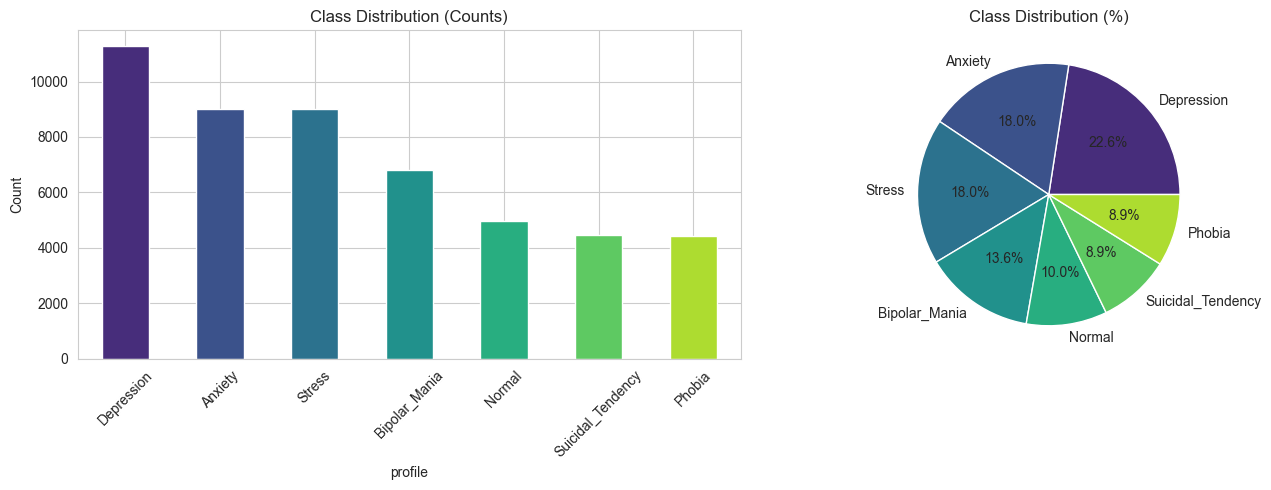


  Label encoding applied:
    Anxiety -> 0
    Bipolar_Mania -> 1
    Depression -> 2
    Normal -> 3
    Phobia -> 4
    Stress -> 5
    Suicidal_Tendency -> 6

  Feature matrix shape: (50000, 65)
  Target array length : 50000

Step 7 complete.


In [26]:
print('=' * 70)
print('STEP 7: TARGET ANALYSIS & CLASS BALANCE CHECK')
print('=' * 70)

if TASK_TYPE == 'classification':
    # ─── Class distribution ──────────────────────────────────────────
    class_counts = df[TARGET_COLUMN].value_counts()
    class_pct = (class_counts / len(df) * 100).round(2)
    n_classes = len(class_counts)

    print(f'\nClass Distribution ({n_classes} classes):')
    for cls in class_counts.index:
        count = class_counts[cls]
        pct = class_pct[cls]
        bar_len = int(pct / 2)
        bar = '#' * bar_len
        print(f'  {str(cls):<30} {count:>8,} ({pct:>6.2f}%) |{bar}')

    # ─── Balance check ───────────────────────────────────────────────
    max_count = class_counts.max()
    min_count = class_counts.min()
    imbalance_ratio = max_count / min_count

    print(f'\nBalance Check:')
    print(f'  Largest class  : {class_counts.idxmax()} ({max_count:,})')
    print(f'  Smallest class : {class_counts.idxmin()} ({min_count:,})')
    print(f'  Imbalance ratio: {imbalance_ratio:.2f}:1')

    # ─── Strategy decision ───────────────────────────────────────────
    if imbalance_ratio <= 1.5:
        BALANCE_STRATEGY = 'none'
        print(f'\n  >> Dataset is BALANCED (ratio <= 1.5)')
        print(f'     Strategy: No class weights or resampling needed.')
    elif imbalance_ratio <= 3.0:
        BALANCE_STRATEGY = 'class_weight'
        print(f'\n  >> Dataset is MODERATELY IMBALANCED (ratio {imbalance_ratio:.1f}:1)')
        print(f'     Strategy: Will use class_weight="balanced" in models.')
        print(f'     This adjusts the loss to penalize minority-class errors more.')
    else:
        BALANCE_STRATEGY = 'class_weight'
        print(f'\n  >> Dataset is HEAVILY IMBALANCED (ratio {imbalance_ratio:.1f}:1)')
        print(f'     Strategy: Will use class_weight="balanced" + stratified sampling.')
        print(f'     Consider collecting more data for minority classes if possible.')

    # ─── Plot ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = sns.color_palette('viridis', n_classes)
    class_counts.plot(kind='bar', ax=axes[0], color=colors)
    axes[0].set_title('Class Distribution (Counts)')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    class_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
    axes[1].set_ylabel('')
    axes[1].set_title('Class Distribution (%)')

    plt.tight_layout()
    plt.show()

    # ─── Encode target ───────────────────────────────────────────────
    le = LabelEncoder()
    y = le.fit_transform(df[TARGET_COLUMN])
    class_names = le.classes_.tolist()
    print(f'\n  Label encoding applied:')
    for name, code in zip(class_names, le.transform(le.classes_)):
        print(f'    {name} -> {code}')

else:
    # ─── Regression target ───────────────────────────────────────────
    BALANCE_STRATEGY = 'none'
    le = None
    y = df[TARGET_COLUMN].values.astype(float)
    class_names = None
    n_classes = None
    imbalance_ratio = None

    print(f'\nTarget Distribution (Regression):')
    print(f'  Mean     : {y.mean():.4f}')
    print(f'  Std      : {y.std():.4f}')
    print(f'  Min      : {y.min():.4f}')
    print(f'  Max      : {y.max():.4f}')
    print(f'  Skewness : {stats.skew(y):.4f}')
    print(f'  Kurtosis : {stats.kurtosis(y):.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_title('Target Distribution')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frequency')

    stats.probplot(y, plot=axes[1])
    axes[1].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

# ─── Separate features from target ──────────────────────────────────
X_df = df.drop(columns=[TARGET_COLUMN])
print(f'\n  Feature matrix shape: {X_df.shape}')
print(f'  Target array length : {len(y)}')

PIPELINE_STATE['target_analysis'] = {
    'task_type': TASK_TYPE,
    'balance_strategy': BALANCE_STRATEGY,
    'n_classes': int(n_classes) if n_classes else None,
    'imbalance_ratio': float(imbalance_ratio) if imbalance_ratio else None,
    'class_names': class_names
}
print(f'\nStep 7 complete.')

## Step 8 — Outlier Handling (Smoothing Only — No Removal!)
For each numeric column with outliers, we test multiple smoothing strategies and pick the one
that best normalizes the distribution. **No data points are ever removed.**

Strategies tested per column:
- **Winsorizing** (cap to IQR bounds)
- **Log1p transform** (for right-skewed, non-negative data)
- **Square root transform** (for moderate skew, non-negative data)
- **Yeo-Johnson transform** (works for any distribution, including negatives)

The strategy producing the lowest absolute skewness wins.

STEP 8: OUTLIER HANDLING (SMOOTHING ONLY)
Strategy: Outliers are NEVER removed.
Instead, we test multiple smoothing techniques per column
and apply the one that best normalizes the distribution.

Analyzing 63 numeric columns for outliers...

  total_word_count:
    Outliers found  : 1797 (3.59%)
    Original skew   : 1.155
    Strategies tested: winsorize, log1p, sqrt, yeo-johnson
      winsorize       -> skew = 0.574
      log1p           -> skew = 0.553
      sqrt            -> skew = 0.306
      yeo-johnson     -> skew = 0.019 <-- BEST
    Applied: yeo-johnson (new skew: 0.019)

  unique_word_count:
    Outliers found  : 1645 (3.29%)
    Original skew   : 1.379
    Strategies tested: winsorize, log1p, sqrt, yeo-johnson
      winsorize       -> skew = 0.700
      log1p           -> skew = 0.434
      sqrt            -> skew = 0.448
      yeo-johnson     -> skew = 0.009 <-- BEST
    Applied: yeo-johnson (new skew: 0.009)

  ttr:
    Outliers found  : 178 (0.36%)
    Original skew   : 

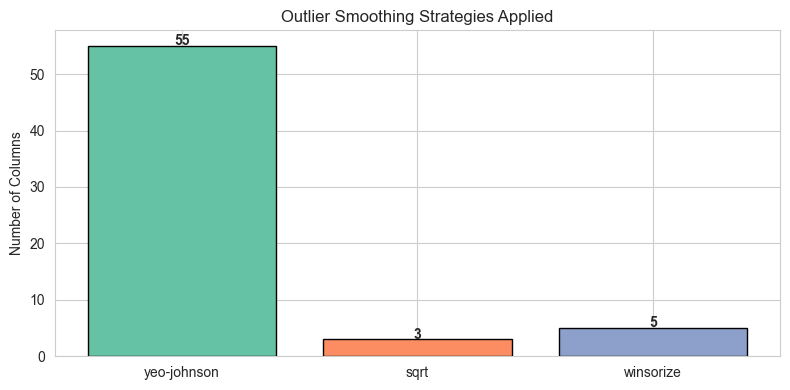


Step 8 complete.


In [27]:
print('=' * 70)
print('STEP 8: OUTLIER HANDLING (SMOOTHING ONLY)')
print('=' * 70)
print('Strategy: Outliers are NEVER removed.')
print('Instead, we test multiple smoothing techniques per column')
print('and apply the one that best normalizes the distribution.\n')

numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
outlier_report = {}
transformations_applied = {}

print(f'Analyzing {len(numeric_cols)} numeric columns for outliers...\n')

for col in numeric_cols:
    values = X_df[col].dropna()
    if len(values) == 0:
        continue

    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = int(((values < lower_bound) | (values > upper_bound)).sum())
    outlier_pct = round(n_outliers / len(values) * 100, 2)

    if n_outliers == 0:
        continue

    original_skew = float(stats.skew(values))
    all_non_negative = (values >= 0).all()

    # Test multiple smoothing strategies
    candidates = {}

    # 1. Winsorizing (capping to IQR bounds)
    capped = values.clip(lower=lower_bound, upper=upper_bound)
    candidates['winsorize'] = abs(float(stats.skew(capped)))

    # 2. Log1p transform (only for non-negative data)
    if all_non_negative:
        log_vals = np.log1p(values)
        candidates['log1p'] = abs(float(stats.skew(log_vals)))

    # 3. Square root transform (only for non-negative data)
    if all_non_negative:
        sqrt_vals = np.sqrt(values)
        candidates['sqrt'] = abs(float(stats.skew(sqrt_vals)))

    # 4. Yeo-Johnson power transform (works for any distribution)
    try:
        pt = PowerTransformer(method='yeo-johnson')
        yj_vals = pt.fit_transform(values.values.reshape(-1, 1)).flatten()
        candidates['yeo-johnson'] = abs(float(stats.skew(yj_vals)))
    except Exception:
        pass

    if not candidates:
        continue

    # Pick strategy with lowest absolute skewness
    best_strategy = min(candidates, key=candidates.get)
    best_skew = candidates[best_strategy]

    # Apply the winning strategy
    if best_strategy == 'winsorize':
        X_df[col] = X_df[col].clip(lower=lower_bound, upper=upper_bound)
    elif best_strategy == 'log1p':
        X_df[col] = np.log1p(X_df[col].clip(lower=0))
    elif best_strategy == 'sqrt':
        X_df[col] = np.sqrt(X_df[col].clip(lower=0))
    elif best_strategy == 'yeo-johnson':
        pt = PowerTransformer(method='yeo-johnson')
        X_df[col] = pt.fit_transform(X_df[col].values.reshape(-1, 1)).flatten()

    transformations_applied[col] = best_strategy
    outlier_report[col] = {
        'n_outliers': n_outliers,
        'outlier_pct': outlier_pct,
        'original_skewness': round(original_skew, 4),
        'strategy_applied': best_strategy,
        'new_skewness': round(best_skew, 4),
        'candidates_tested': {k: round(v, 4) for k, v in candidates.items()}
    }

    print(f'  {col}:')
    print(f'    Outliers found  : {n_outliers} ({outlier_pct}%)')
    print(f'    Original skew   : {original_skew:.3f}')
    print(f'    Strategies tested: {", ".join(candidates.keys())}')
    for strat, sk in candidates.items():
        marker = ' <-- BEST' if strat == best_strategy else ''
        print(f'      {strat:<15} -> skew = {sk:.3f}{marker}')
    print(f'    Applied: {best_strategy} (new skew: {best_skew:.3f})')
    print()

# ─── Summary ─────────────────────────────────────────────────────────
if not outlier_report:
    print('No significant outliers detected in any column. Data looks clean.')
else:
    strategies_used = Counter(transformations_applied.values())
    print(f'--- Outlier Handling Summary ---')
    print(f'  Columns with outliers treated: {len(outlier_report)}')
    print(f'  Strategies breakdown:')
    for strat, count in strategies_used.most_common():
        print(f'    {strat}: {count} columns')

    fig, ax = plt.subplots(figsize=(8, 4))
    strat_names = list(strategies_used.keys())
    strat_counts = list(strategies_used.values())
    ax.bar(strat_names, strat_counts, color=sns.color_palette('Set2', len(strat_names)),
           edgecolor='black')
    ax.set_title('Outlier Smoothing Strategies Applied')
    ax.set_ylabel('Number of Columns')
    for i, (name, cnt) in enumerate(zip(strat_names, strat_counts)):
        ax.text(i, cnt + 0.1, str(cnt), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

PIPELINE_STATE['outlier_handling'] = {
    'total_columns_with_outliers': len(outlier_report),
    'transformations': transformations_applied,
    'details': outlier_report
}
print(f'\nStep 8 complete.')

## Step 9 — Feature Type Handling
Encode categorical features, convert booleans, and ensure all features are numeric for modeling.

Encoding strategies:
- **Binary** (2 unique values) → Label Encoding
- **Low cardinality** (3-10 unique) → One-Hot Encoding
- **Medium cardinality** (11+) → Frequency Encoding

In [ ]:
print('=' * 70)
print('STEP 9: FEATURE TYPE HANDLING')
print('=' * 70)

numeric_cols_pre = X_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_df.select_dtypes(include=['object', 'category']).columns.tolist()
bool_cols = X_df.select_dtypes(include=['bool']).columns.tolist()

print(f'\nFeature breakdown:')
print(f'  Numeric     : {len(numeric_cols_pre)} columns')
print(f'  Categorical : {len(categorical_cols)} columns')
print(f'  Boolean     : {len(bool_cols)} columns')

encoding_report = {}

# ─── Encode Categoricals ────────────────────────────────────────────
if categorical_cols:
    print(f'\n--- Encoding Categorical Columns ---')
    for col in categorical_cols:
        n_unique = X_df[col].nunique()

        if n_unique <= 2:
            # Binary -> Label encode
            le_col = LabelEncoder()
            X_df[col] = le_col.fit_transform(X_df[col].astype(str))
            mapping = dict(zip(le_col.classes_.tolist(),
                               [int(x) for x in le_col.transform(le_col.classes_)]))
            encoding_report[col] = {'method': 'label_encoding', 'n_unique': n_unique,
                                    'mapping': mapping}
            print(f'  {col}: Binary ({n_unique}) -> Label Encoded {mapping}')

        elif n_unique <= 10:
            # Low cardinality -> One-hot encode
            dummies = pd.get_dummies(X_df[col], prefix=col, drop_first=True, dtype=int)
            X_df = pd.concat([X_df.drop(columns=[col]), dummies], axis=1)
            new_cols = dummies.columns.tolist()
            encoding_report[col] = {'method': 'one_hot_encoding', 'n_unique': n_unique,
                                    'new_columns': new_cols}
            print(f'  {col}: {n_unique} categories -> One-Hot ({len(new_cols)} new columns)')

        else:
            # Medium+ cardinality -> Frequency encode
            freq_map = X_df[col].value_counts(normalize=True).to_dict()
            X_df[col] = X_df[col].map(freq_map).fillna(0).astype(float)
            encoding_report[col] = {'method': 'frequency_encoding', 'n_unique': n_unique}
            print(f'  {col}: {n_unique} categories -> Frequency Encoded')
else:
    print(f'\n  No categorical columns to encode.')

# ─── Convert Booleans ───────────────────────────────────────────────
if bool_cols:
    print(f'\n--- Converting Boolean Columns ---')
    for col in bool_cols:
        X_df[col] = X_df[col].astype(int)
        print(f'  {col}: bool -> int')

# ─── Final check ────────────────────────────────────────────────────
numeric_cols_final = X_df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric = [c for c in X_df.columns if c not in numeric_cols_final]

if non_numeric:
    print(f'\n  WARNING: {len(non_numeric)} column(s) still non-numeric: {non_numeric}')
    print(f'  Dropping them to proceed safely.')
    X_df = X_df.drop(columns=non_numeric)

print(f'\n  All features are now numeric: {X_df.shape[1]} columns')
print(f'  Shape: {X_df.shape}')

PIPELINE_STATE['feature_handling'] = {
    'original_numeric': len(numeric_cols_pre),
    'original_categorical': len(categorical_cols),
    'encodings': encoding_report,
    'final_feature_count': int(X_df.shape[1])
}
print(f'\nStep 9 complete.')

STEP 9: FEATURE TYPE HANDLING

Feature breakdown:
  Numeric     : 63 columns
  Categorical : 2 columns
  Boolean     : 0 columns

--- Encoding Categorical Columns ---
  language: 3 categories -> One-Hot (2 new columns)
  target: 7 categories -> One-Hot (6 new columns)

  Dropping them to proceed safely.

  All features are now numeric: 63 columns
  Shape: (50000, 63)

Step 9 complete.


## Step 10 — Exploratory Data Analysis & Visualization
Run distribution analysis, correlation analysis, and statistical tests to understand feature-target relationships.

STEP 10: EXPLORATORY DATA ANALYSIS & VISUALIZATION

Analyzing 5 numeric features...

--- 10.1 Feature Distribution Analysis ---
  Top 10 most skewed features:
    topic_shift_frequency               skew= -0.077  kurtosis= -0.371  [LOW]
    semantic_coherence_score            skew= -0.041  kurtosis= -0.379  [LOW]
    overall_sentiment_score             skew= -0.022  kurtosis= -0.190  [LOW]
    total_word_count                    skew=  0.019  kurtosis=  0.422  [LOW]
    unique_word_count                   skew=  0.009  kurtosis=  0.226  [LOW]


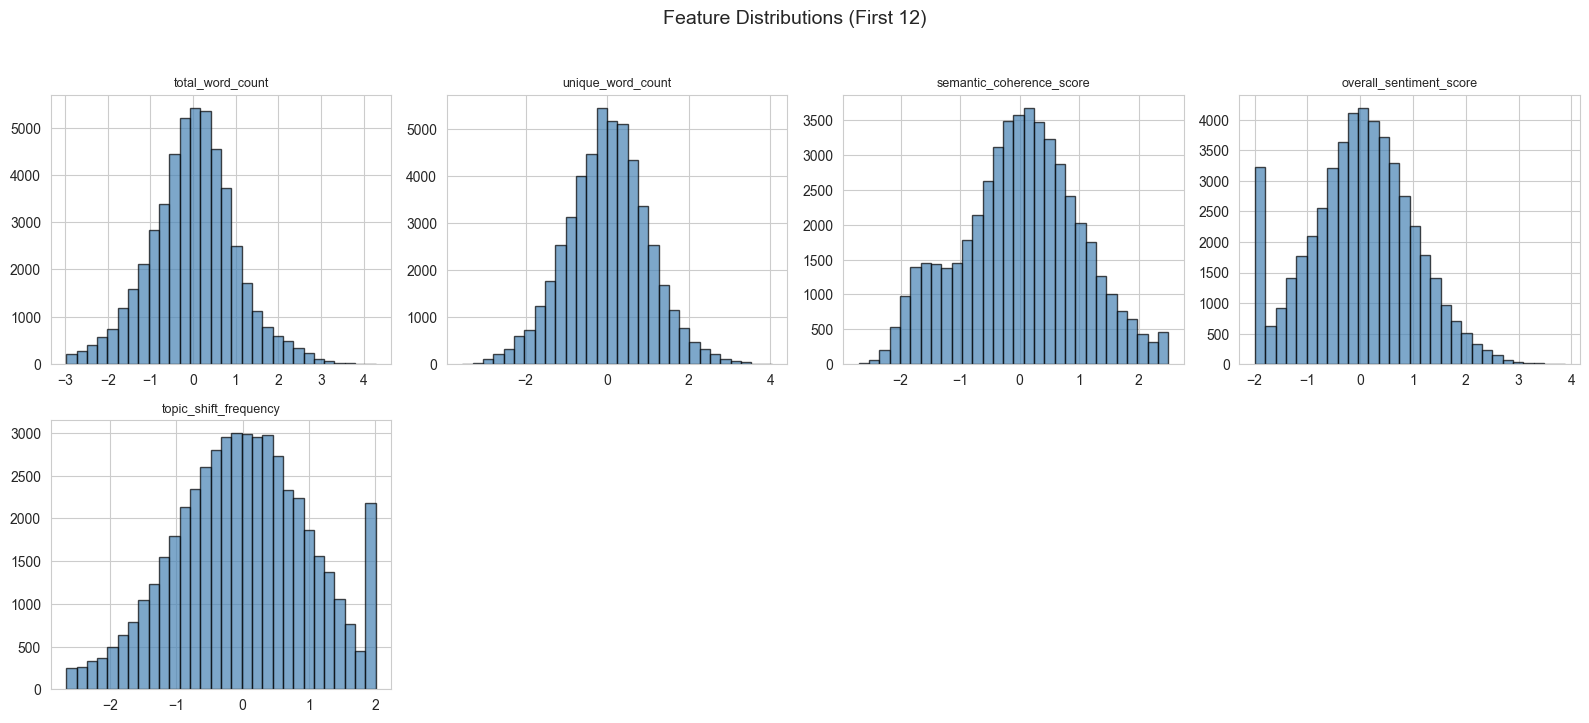


--- 10.2 Correlation Analysis ---
  Found 1 highly correlated pairs (|r| >= 0.85):
    total_word_count <-> unique_word_count: r = 0.885


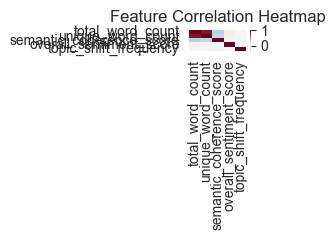


--- 10.3 Statistical Tests (Feature vs Target) ---
  Running Kruskal-Wallis H-test (non-parametric) for each feature vs target...
  Results: 5/5 features are statistically significant (p < 0.05)

  Top 10 features by H-statistic:
    overall_sentiment_score             H=  24571.75  p=0.00e+00  [SIG]
    semantic_coherence_score            H=  18392.29  p=0.00e+00  [SIG]
    total_word_count                    H=   8524.51  p=0.00e+00  [SIG]
    unique_word_count                   H=   6738.94  p=0.00e+00  [SIG]
    topic_shift_frequency               H=    144.14  p=1.34e-28  [SIG]

--- 10.4 Box Plots by Class (Top 8 Features) ---


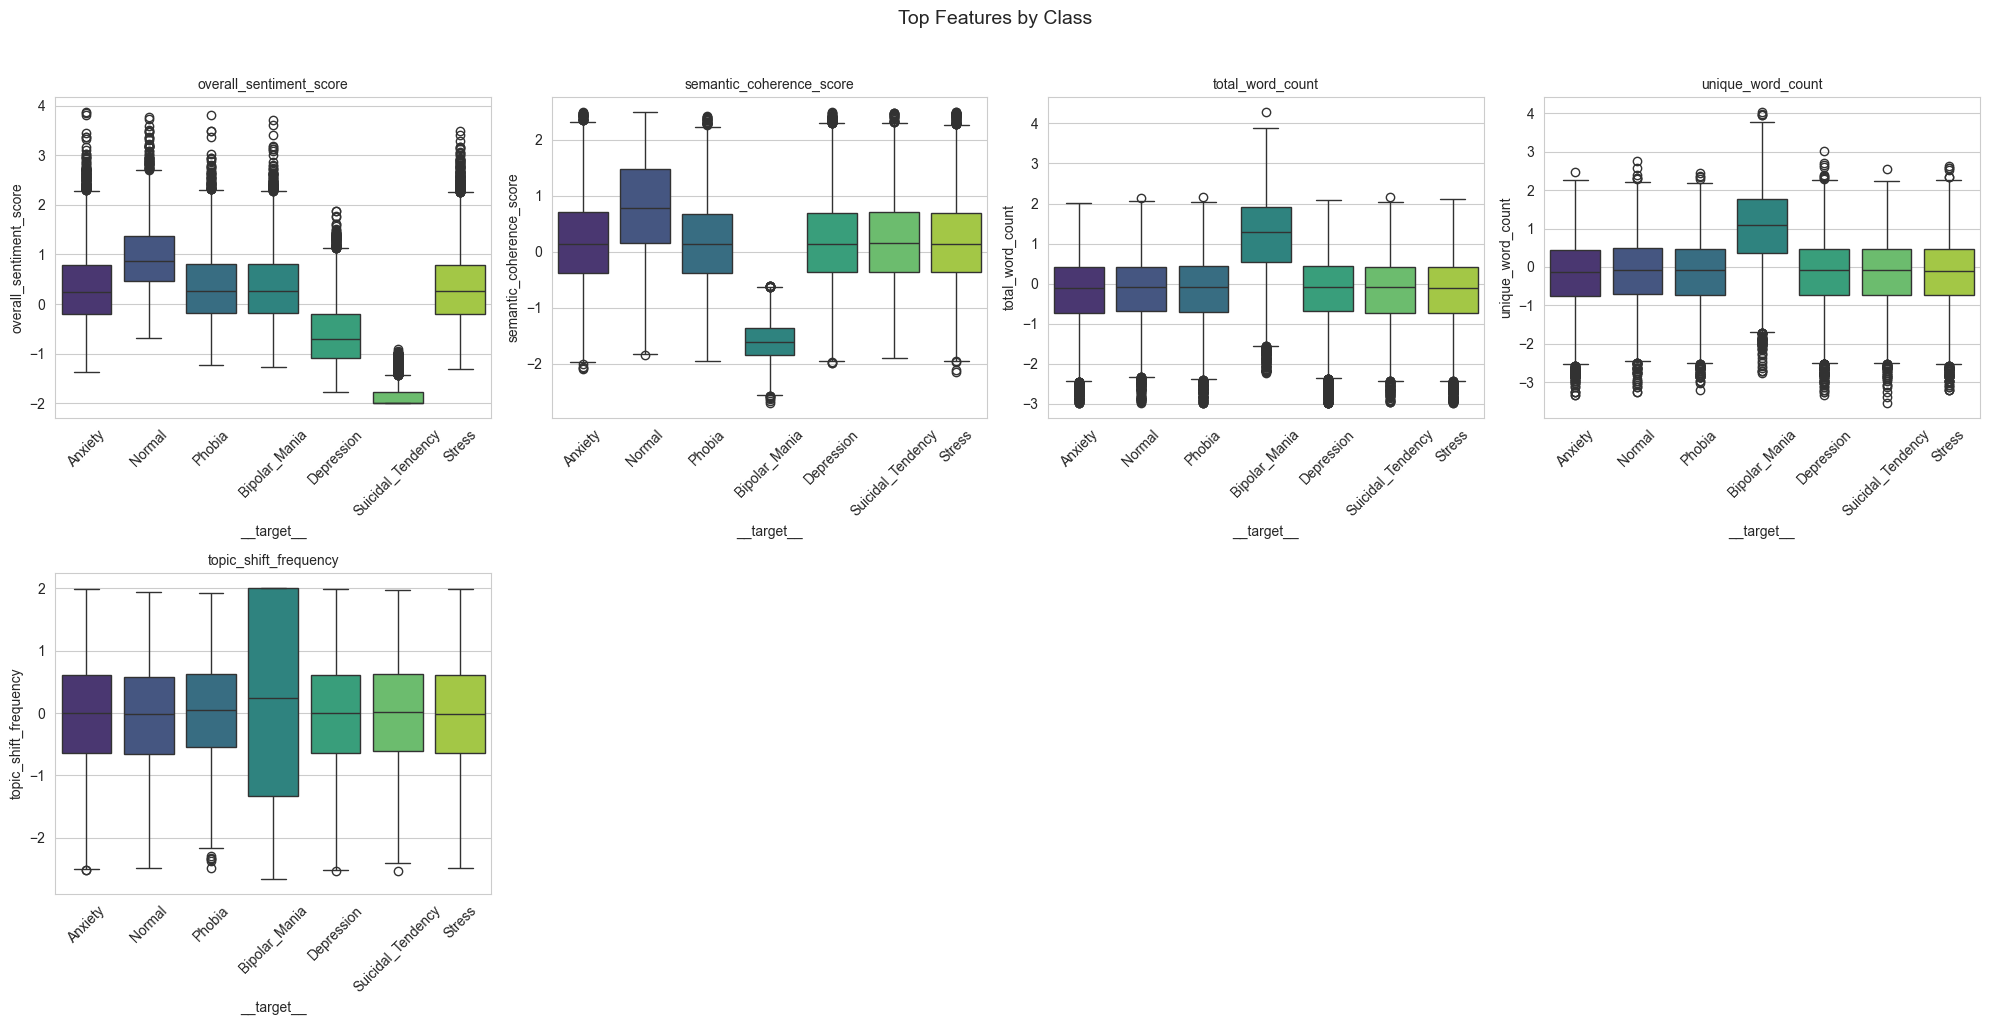


Step 10 complete.


In [15]:
print('=' * 70)
print('STEP 10: EXPLORATORY DATA ANALYSIS & VISUALIZATION')
print('=' * 70)

numeric_cols_eda = X_df.select_dtypes(include=[np.number]).columns.tolist()
n_feat = len(numeric_cols_eda)
print(f'\nAnalyzing {n_feat} numeric features...\n')

# ─── 10.1 Distribution Analysis ─────────────────────────────────────
print('--- 10.1 Feature Distribution Analysis ---')
skewness_report = {}
for col in numeric_cols_eda:
    vals = X_df[col].dropna()
    sk = float(stats.skew(vals)) if len(vals) > 2 else 0.0
    kt = float(stats.kurtosis(vals)) if len(vals) > 2 else 0.0
    skewness_report[col] = {'skewness': round(sk, 4), 'kurtosis': round(kt, 4)}

sorted_skew = sorted(skewness_report.items(), key=lambda x: abs(x[1]['skewness']),
                      reverse=True)
print(f'  Top 10 most skewed features:')
for col, vals in sorted_skew[:10]:
    label = 'HIGH' if abs(vals['skewness']) > 2 else 'MOD' if abs(vals['skewness']) > 1 else 'LOW'
    print(f'    {col:<35} skew={vals["skewness"]:>7.3f}  kurtosis={vals["kurtosis"]:>7.3f}  [{label}]')

# Plot distributions (first 12 features)
n_plot = min(12, n_feat)
if n_plot > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.flatten()
    for i in range(n_plot):
        col = numeric_cols_eda[i]
        axes[i].hist(X_df[col].dropna(), bins=30, edgecolor='black', alpha=0.7,
                     color='steelblue')
        axes[i].set_title(col, fontsize=9)
    for i in range(n_plot, len(axes)):
        axes[i].set_visible(False)
    plt.suptitle('Feature Distributions (First 12)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# ─── 10.2 Correlation Analysis ──────────────────────────────────────
print('\n--- 10.2 Correlation Analysis ---')
corr_matrix = X_df[numeric_cols_eda].corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = abs(corr_matrix.iloc[i, j])
        if r >= 0.85:
            high_corr_pairs.append((corr_matrix.columns[i],
                                    corr_matrix.columns[j],
                                    round(float(r), 4)))

if high_corr_pairs:
    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
    print(f'  Found {len(high_corr_pairs)} highly correlated pairs (|r| >= 0.85):')
    for c1, c2, r in high_corr_pairs[:15]:
        print(f'    {c1} <-> {c2}: r = {r}')
    if len(high_corr_pairs) > 15:
        print(f'    ... and {len(high_corr_pairs) - 15} more pairs')
else:
    print('  No highly correlated pairs found (|r| >= 0.85). Features are independent.')

# Heatmap
if n_feat <= 40:
    fig, ax = plt.subplots(figsize=(min(18, n_feat * 0.6), min(14, n_feat * 0.5)))
    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, ax=ax,
                xticklabels=True, yticklabels=True, fmt='.1f')
    ax.set_title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print(f'  Skipping full heatmap ({n_feat} features too many). Showing top correlations only.')
    # Show top correlated subset
    if high_corr_pairs:
        top_cols = list(set([c1 for c1, _, _ in high_corr_pairs[:10]] +
                            [c2 for _, c2, _ in high_corr_pairs[:10]]))[:20]
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix.loc[top_cols, top_cols], cmap='RdBu_r', center=0,
                    ax=ax, annot=True, fmt='.2f')
        ax.set_title('Correlation Heatmap (Top Correlated Features)')
        plt.tight_layout()
        plt.show()

# ─── 10.3 Statistical Tests ─────────────────────────────────────────
print('\n--- 10.3 Statistical Tests (Feature vs Target) ---')
stat_test_results = {}

if TASK_TYPE == 'classification':
    print('  Running Kruskal-Wallis H-test (non-parametric) for each feature vs target...')
    classes_unique = df[TARGET_COLUMN].unique()

    for col in numeric_cols_eda:
        groups = [X_df[col][df[TARGET_COLUMN] == c].dropna().values
                  for c in classes_unique]
        groups = [g for g in groups if len(g) >= 2]
        if len(groups) >= 2:
            h_stat, p_val = stats.kruskal(*groups)
            stat_test_results[col] = {
                'test': 'kruskal_wallis',
                'H_statistic': round(float(h_stat), 4),
                'p_value': float(p_val),
                'significant': bool(p_val < 0.05)
            }

    sig_count = sum(1 for v in stat_test_results.values() if v['significant'])
    print(f'  Results: {sig_count}/{len(stat_test_results)} features are statistically '
          f'significant (p < 0.05)')

    sorted_tests = sorted(stat_test_results.items(),
                           key=lambda x: x[1]['H_statistic'], reverse=True)
    print(f'\n  Top 10 features by H-statistic:')
    for col, vals in sorted_tests[:10]:
        sig = 'SIG' if vals['significant'] else 'n.s.'
        print(f'    {col:<35} H={vals["H_statistic"]:>10.2f}  '
              f'p={vals["p_value"]:.2e}  [{sig}]')

else:
    print('  Running Spearman correlation for each feature vs target...')
    for col in numeric_cols_eda:
        vals = X_df[col].dropna()
        target_aligned = y[:len(vals)]
        if len(vals) >= 3:
            rho, p_val = stats.spearmanr(vals, target_aligned)
            stat_test_results[col] = {
                'test': 'spearman_correlation',
                'rho': round(float(rho), 4),
                'p_value': float(p_val),
                'significant': bool(p_val < 0.05)
            }

    sig_count = sum(1 for v in stat_test_results.values() if v['significant'])
    sorted_tests = sorted(stat_test_results.items(),
                           key=lambda x: abs(x[1]['rho']), reverse=True)
    print(f'  Results: {sig_count}/{len(stat_test_results)} features significant (p < 0.05)')
    print(f'\n  Top 10 features by |rho|:')
    for col, vals in sorted_tests[:10]:
        sig = 'SIG' if vals['significant'] else 'n.s.'
        print(f'    {col:<35} rho={vals["rho"]:>7.4f}  p={vals["p_value"]:.2e}  [{sig}]')

# ─── 10.4 Box Plots by Class (classification) ───────────────────────
if TASK_TYPE == 'classification' and len(sorted_tests) > 0:
    print(f'\n--- 10.4 Box Plots by Class (Top 8 Features) ---')
    top_feat_names = [col for col, _ in sorted_tests[:8]]
    n_bp = min(8, len(top_feat_names))

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    plot_df = X_df.copy()
    plot_df['__target__'] = df[TARGET_COLUMN].values

    for i in range(n_bp):
        col = top_feat_names[i]
        sns.boxplot(data=plot_df, x='__target__', y=col, ax=axes[i],
                    palette='viridis')
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
    for i in range(n_bp, len(axes)):
        axes[i].set_visible(False)
    plt.suptitle('Top Features by Class', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

PIPELINE_STATE['eda'] = {
    'n_features_analyzed': n_feat,
    'high_corr_pairs_count': len(high_corr_pairs),
    'significant_features': sig_count,
    'skewness': skewness_report
}
print(f'\nStep 10 complete.')

## Step 11 — Feature Selection (Multi-Method Consensus)
Use three independent methods to rank features, then combine into a consensus ranking:
1. **Random Forest** feature importance (MDI)
2. **Mutual Information** scores
3. **Statistical tests** (Kruskal-Wallis H / Spearman rho)

Bottom 30% features by consensus rank are dropped.

STEP 11: FEATURE SELECTION (MULTI-METHOD CONSENSUS)

Starting with 5 features.

--- 11.1 Correlation-Based Filtering ---
  Removing 1 redundant features:
    [-] unique_word_count

--- 11.2 Random Forest Feature Importance ---
  Top 15 by RF Importance:
    overall_sentiment_score             0.3594 |#######################################################################
    semantic_coherence_score            0.2870 |#########################################################
    total_word_count                    0.1788 |###################################
    topic_shift_frequency               0.1749 |##################################

--- 11.3 Mutual Information Scores ---
  Top 15 by Mutual Information:
    overall_sentiment_score             0.4734 |#######################
    semantic_coherence_score            0.3297 |################
    total_word_count                    0.1436 |#######
    topic_shift_frequency               0.1311 |######

--- 11.4 Consensus Feature Ranki

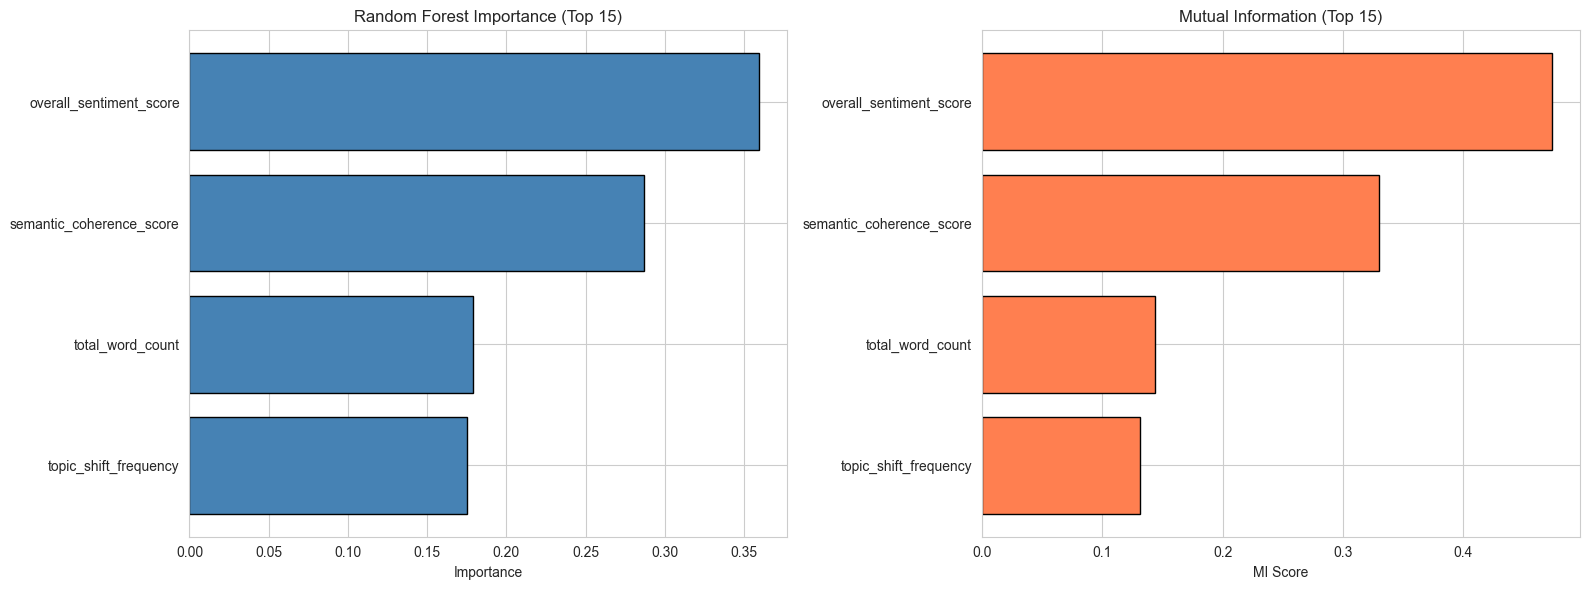


  Final feature count: 4

Step 11 complete.


In [16]:
print('=' * 70)
print('STEP 11: FEATURE SELECTION (MULTI-METHOD CONSENSUS)')
print('=' * 70)

numeric_cols_fs = X_df.select_dtypes(include=[np.number]).columns.tolist()
n_features_start = len(numeric_cols_fs)
print(f'\nStarting with {n_features_start} features.')

# ─── 11.1 Remove Highly Correlated Features ─────────────────────────
print(f'\n--- 11.1 Correlation-Based Filtering ---')
cols_to_remove_corr = set()

if high_corr_pairs:
    for c1, c2, r in high_corr_pairs:
        if c1 not in numeric_cols_fs or c2 not in numeric_cols_fs:
            continue
        # Keep the feature more related to target
        if TASK_TYPE == 'classification':
            score1 = stat_test_results.get(c1, {}).get('H_statistic', 0)
            score2 = stat_test_results.get(c2, {}).get('H_statistic', 0)
        else:
            score1 = abs(stat_test_results.get(c1, {}).get('rho', 0))
            score2 = abs(stat_test_results.get(c2, {}).get('rho', 0))
        remove = c2 if score1 >= score2 else c1
        if remove in numeric_cols_fs:
            cols_to_remove_corr.add(remove)

    if cols_to_remove_corr:
        print(f'  Removing {len(cols_to_remove_corr)} redundant features:')
        for col in sorted(cols_to_remove_corr):
            print(f'    [-] {col}')
        X_df = X_df.drop(columns=list(cols_to_remove_corr), errors='ignore')
    else:
        print('  No features removed after correlation analysis.')
else:
    print('  No highly correlated pairs to filter.')

numeric_cols_fs = X_df.select_dtypes(include=[np.number]).columns.tolist()

# ─── 11.2 Random Forest Feature Importance ──────────────────────────
print(f'\n--- 11.2 Random Forest Feature Importance ---')
sample_size = min(len(X_df), 30000)
idx = np.random.choice(len(X_df), sample_size, replace=False)
X_sample = X_df.iloc[idx][numeric_cols_fs].values
y_sample = y[idx]

if TASK_TYPE == 'classification':
    rf_imp_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
else:
    rf_imp_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)

rf_imp_model.fit(X_sample, y_sample)
rf_importance = dict(zip(numeric_cols_fs, rf_imp_model.feature_importances_))
rf_sorted = sorted(rf_importance.items(), key=lambda x: x[1], reverse=True)

print(f'  Top 15 by RF Importance:')
for col, imp in rf_sorted[:15]:
    bar = '#' * int(imp * 200)
    print(f'    {col:<35} {imp:.4f} |{bar}')

# ─── 11.3 Mutual Information ────────────────────────────────────────
print(f'\n--- 11.3 Mutual Information Scores ---')
mi_func = mutual_info_classif if TASK_TYPE == 'classification' else mutual_info_regression
mi_scores = mi_func(X_df[numeric_cols_fs].fillna(0).values, y, random_state=RANDOM_SEED)
mi_importance = dict(zip(numeric_cols_fs, mi_scores))
mi_sorted = sorted(mi_importance.items(), key=lambda x: x[1], reverse=True)

print(f'  Top 15 by Mutual Information:')
for col, mi in mi_sorted[:15]:
    bar = '#' * int(mi * 50)
    print(f'    {col:<35} {mi:.4f} |{bar}')

# ─── 11.4 Consensus Ranking ─────────────────────────────────────────
print(f'\n--- 11.4 Consensus Feature Ranking ---')
rf_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(rf_sorted)}
mi_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(mi_sorted)}

# Statistical test ranking
if TASK_TYPE == 'classification':
    stat_filtered = [(col, stat_test_results[col]['H_statistic'])
                     for col in numeric_cols_fs if col in stat_test_results]
    stat_sorted_fs = sorted(stat_filtered, key=lambda x: x[1], reverse=True)
else:
    stat_filtered = [(col, abs(stat_test_results[col]['rho']))
                     for col in numeric_cols_fs if col in stat_test_results]
    stat_sorted_fs = sorted(stat_filtered, key=lambda x: x[1], reverse=True)

stat_ranks = {feat: rank + 1 for rank, (feat, _) in enumerate(stat_sorted_fs)}

consensus = {}
for feat in numeric_cols_fs:
    ranks = [
        rf_ranks.get(feat, len(numeric_cols_fs)),
        mi_ranks.get(feat, len(numeric_cols_fs)),
        stat_ranks.get(feat, len(numeric_cols_fs))
    ]
    consensus[feat] = np.mean(ranks)

consensus_sorted = sorted(consensus.items(), key=lambda x: x[1])
n_total = len(consensus_sorted)

print(f'  Consensus Ranking (average of RF + MI + Stat ranks):')
for rank, (feat, avg_rank) in enumerate(consensus_sorted[:20], 1):
    pct = rank / n_total * 100
    tier = 'T1' if pct <= 15 else 'T2' if pct <= 40 else 'T3' if pct <= 70 else 'T4'
    print(f'    {rank:>3}. [{tier}] {feat:<35} avg_rank: {avg_rank:.1f}')
if n_total > 20:
    print(f'    ... ({n_total - 20} more features)')

# ─── 11.5 Feature Pruning ───────────────────────────────────────────
print(f'\n--- 11.5 Feature Pruning ---')
keep_n = max(int(n_total * 0.7), min(n_total, 5))
features_to_keep = [feat for feat, _ in consensus_sorted[:keep_n]]
features_to_drop = [feat for feat, _ in consensus_sorted[keep_n:]]

if features_to_drop:
    print(f'  Keeping top {keep_n}/{n_total} features (top 70%)')
    print(f'  Dropping {len(features_to_drop)} low-importance features:')
    for feat in features_to_drop:
        print(f'    [-] {feat} (avg rank: {consensus[feat]:.1f})')
    X_df = X_df[features_to_keep]
else:
    print(f'  All {n_total} features retained (dataset has few features).')

# ─── Importance Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, min(12, n_features_start * 0.3))))

top_rf = rf_sorted[:15]
axes[0].barh([x[0] for x in top_rf][::-1], [x[1] for x in top_rf][::-1],
             color='steelblue', edgecolor='black')
axes[0].set_title('Random Forest Importance (Top 15)')
axes[0].set_xlabel('Importance')

top_mi = mi_sorted[:15]
axes[1].barh([x[0] for x in top_mi][::-1], [x[1] for x in top_mi][::-1],
             color='coral', edgecolor='black')
axes[1].set_title('Mutual Information (Top 15)')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

print(f'\n  Final feature count: {X_df.shape[1]}')

PIPELINE_STATE['feature_selection'] = {
    'initial_features': n_features_start,
    'removed_correlation': list(cols_to_remove_corr),
    'consensus_top_20': [(f, round(float(r), 2)) for f, r in consensus_sorted[:20]],
    'features_kept': features_to_keep,
    'features_dropped': features_to_drop,
    'final_count': int(X_df.shape[1])
}
print(f'\nStep 11 complete.')

## Step 12 — Preprocessing Finalization
Train/test split and feature scaling. The scaler is chosen based on data characteristics.

In [17]:
print('=' * 70)
print('STEP 12: PREPROCESSING FINALIZATION')
print('=' * 70)

feature_names = X_df.columns.tolist()
X = X_df.values.astype(np.float64)

# Handle any remaining NaN/Inf
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
if nan_count > 0 or inf_count > 0:
    print(f'\n  Cleaning: {nan_count} NaN, {inf_count} Inf values found. Replacing...')
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f'\nFinal feature matrix: {X.shape}')
print(f'Target array: {y.shape}')

# ─── Train/Test Split ───────────────────────────────────────────────
if TASK_TYPE == 'classification':
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
    )
    print(f'\nStratified Train/Test Split (80/20):')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED
    )
    print(f'\nTrain/Test Split (80/20):')

print(f'  Train: {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'  Test : {X_test.shape[0]:,} samples, {X_test.shape[1]} features')

if TASK_TYPE == 'classification':
    print(f'\n  Train class distribution:')
    train_counts = Counter(y_train)
    for cls_idx in sorted(train_counts.keys()):
        cls_name = class_names[cls_idx] if class_names else str(cls_idx)
        count = train_counts[cls_idx]
        print(f'    {cls_name}: {count:,}')

# ─── Scaler Selection ───────────────────────────────────────────────
print(f'\n--- Scaler Selection ---')
n_outlier_cols = len(PIPELINE_STATE.get('outlier_handling', {}).get('transformations', {}))
total_numeric = len(feature_names)

if n_outlier_cols > total_numeric * 0.3:
    scaler = RobustScaler()
    scaler_name = 'RobustScaler'
    print(f'  Many columns required outlier smoothing ({n_outlier_cols}/{total_numeric}).')
    print(f'  Using RobustScaler (median/IQR based) for extra robustness.')
else:
    scaler = StandardScaler()
    scaler_name = 'StandardScaler'
    print(f'  Outlier situation is manageable ({n_outlier_cols}/{total_numeric} columns treated).')
    print(f'  Using StandardScaler (zero mean, unit variance).')

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\n  Scaling applied with {scaler_name}')
print(f'  Train — mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}')
print(f'  Test  — mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}')

PIPELINE_STATE['preprocessing'] = {
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'train_size': int(X_train.shape[0]),
    'test_size': int(X_test.shape[0]),
    'scaler': scaler_name,
    'class_names': class_names
}
print(f'\nStep 12 complete.')

STEP 12: PREPROCESSING FINALIZATION

Final feature matrix: (50000, 4)
Target array: (50000,)

Stratified Train/Test Split (80/20):
  Train: 40,000 samples, 4 features
  Test : 10,000 samples, 4 features

  Train class distribution:
    Anxiety: 7,219
    Bipolar_Mania: 5,454
    Depression: 9,025
    Normal: 3,982
    Phobia: 3,551
    Stress: 7,200
    Suicidal_Tendency: 3,569

--- Scaler Selection ---
  Many columns required outlier smoothing (5/4).
  Using RobustScaler (median/IQR based) for extra robustness.

  Scaling applied with RobustScaler
  Train — mean: -0.018305, std: 0.769552
  Test  — mean: -0.014556, std: 0.769498

Step 12 complete.


## Step 13 — Model Shortlisting
Dynamically select candidate models based on dataset properties (size, dimensionality, task type).

In [18]:
print('=' * 70)
print('STEP 13: MODEL SHORTLISTING')
print('=' * 70)

n_samples = X_train_scaled.shape[0]
n_feats = X_train_scaled.shape[1]

print(f'\nData characteristics:')
print(f'  Training samples : {n_samples:,}')
print(f'  Features         : {n_feats}')
print(f'  Task             : {TASK_TYPE}')
if TASK_TYPE == 'classification':
    print(f'  Classes          : {len(class_names) if class_names else "N/A"}')
    print(f'  Balance strategy : {BALANCE_STRATEGY}')

candidates = OrderedDict()
selection_reasons = {}
use_cw = BALANCE_STRATEGY in ['class_weight', 'class_weight_heavy']

if TASK_TYPE == 'classification':
    # --- Always include ---
    candidates['Random Forest'] = RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1,
        class_weight='balanced' if use_cw else None)
    selection_reasons['Random Forest'] = 'Always included — robust, handles mixed features'

    candidates['LightGBM'] = lgb.LGBMClassifier(
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
        is_unbalance=use_cw)
    selection_reasons['LightGBM'] = 'Always included — fast, state-of-the-art for tabular data'

    candidates['Extra Trees'] = ExtraTreesClassifier(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1,
        class_weight='balanced' if use_cw else None)
    selection_reasons['Extra Trees'] = 'Always included — more randomized variant of RF'

    # --- Conditional ---
    if n_samples <= 100000:
        candidates['XGBoost'] = xgb.XGBClassifier(
            random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss')
        selection_reasons['XGBoost'] = f'Included — dataset size ({n_samples:,}) manageable for XGBoost'
    else:
        selection_reasons['XGBoost [SKIPPED]'] = f'Skipped — too large ({n_samples:,}), prefer LightGBM'
        print(f'  Skipping XGBoost: dataset too large ({n_samples:,}). LightGBM preferred.')

    candidates['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=200, random_state=RANDOM_SEED)
    selection_reasons['Gradient Boosting'] = 'Included — strong boosting baseline'

    if n_feats < 100 and n_samples <= 50000:
        candidates['Logistic Regression'] = LogisticRegression(
            random_state=RANDOM_SEED, max_iter=1000, n_jobs=-1,
            class_weight='balanced' if use_cw else None)
        selection_reasons['Logistic Regression'] = (
            f'Included — {n_feats} features, {n_samples:,} samples, linear baseline feasible')

    if n_feats < 50 and n_samples <= 20000:
        candidates['SVM (RBF)'] = SVC(
            random_state=RANDOM_SEED, probability=True,
            class_weight='balanced' if use_cw else None)
        selection_reasons['SVM (RBF)'] = (
            f'Included — {n_feats} features, {n_samples:,} samples, SVM feasible')

    if n_samples <= 50000:
        candidates['KNN'] = KNeighborsClassifier(n_jobs=-1)
        selection_reasons['KNN'] = f'Included — dataset size ({n_samples:,}) manageable for KNN'

else:  # regression
    candidates['Random Forest'] = RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    selection_reasons['Random Forest'] = 'Always included — robust baseline'

    candidates['LightGBM'] = lgb.LGBMRegressor(
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
    selection_reasons['LightGBM'] = 'Always included — fast, state-of-the-art'

    candidates['Extra Trees'] = ExtraTreesRegressor(
        n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    selection_reasons['Extra Trees'] = 'Always included — randomized variant'

    if n_samples <= 100000:
        candidates['XGBoost'] = xgb.XGBRegressor(
            random_state=RANDOM_SEED, n_jobs=-1)
        selection_reasons['XGBoost'] = f'Included — manageable size ({n_samples:,})'

    candidates['Gradient Boosting'] = GradientBoostingRegressor(
        n_estimators=200, random_state=RANDOM_SEED)
    selection_reasons['Gradient Boosting'] = 'Included — strong boosting baseline'

    if n_feats < 100:
        candidates['Ridge'] = Ridge(alpha=1.0)
        selection_reasons['Ridge'] = f'Included — {n_feats} features, linear baseline'

    if n_feats < 50 and n_samples <= 20000:
        candidates['SVR'] = SVR()
        selection_reasons['SVR'] = f'Included — small enough for SVR'

    if n_samples <= 50000:
        candidates['KNN'] = KNeighborsRegressor(n_jobs=-1)
        selection_reasons['KNN'] = f'Included — manageable size ({n_samples:,})'

print(f'\nSelected {len(candidates)} candidate models:\n')
for name in candidates:
    reason = selection_reasons.get(name, '')
    print(f'  [+] {name}')
    print(f'      {reason}\n')

for name, reason in selection_reasons.items():
    if 'SKIPPED' in name:
        print(f'  [-] {name}')
        print(f'      {reason}\n')

PIPELINE_STATE['model_shortlist'] = {
    'n_candidates': len(candidates),
    'models': list(candidates.keys()),
    'reasons': selection_reasons
}
print(f'\nStep 13 complete.')

STEP 13: MODEL SHORTLISTING

Data characteristics:
  Training samples : 40,000
  Features         : 4
  Task             : classification
  Classes          : 7
  Balance strategy : class_weight

Selected 7 candidate models:

  [+] Random Forest
      Always included — robust, handles mixed features

  [+] LightGBM
      Always included — fast, state-of-the-art for tabular data

  [+] Extra Trees
      Always included — more randomized variant of RF

  [+] XGBoost
      Included — dataset size (40,000) manageable for XGBoost

  [+] Gradient Boosting
      Included — strong boosting baseline

  [+] Logistic Regression
      Included — 4 features, 40,000 samples, linear baseline feasible

  [+] KNN
      Included — dataset size (40,000) manageable for KNN


Step 13 complete.


## Step 14 — Model Training & Cross-Validation Ranking
Train all candidate models with cross-validation and rank them by score.

In [19]:
print('=' * 70)
print('STEP 14: MODEL TRAINING & CROSS-VALIDATION')
print('=' * 70)

n_folds = 5
if TASK_TYPE == 'classification':
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    scoring = 'f1_weighted' if (class_names and len(class_names) > 2) else 'f1'
else:
    cv = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    scoring = 'neg_mean_squared_error'

print(f'\nCross-Validation Setup:')
print(f'  Folds   : {n_folds}')
print(f'  Scoring  : {scoring}')
print(f'  Samples  : {X_train_scaled.shape[0]:,}')
print(f'  Features : {X_train_scaled.shape[1]}\n')

model_results = {}

for name, model in candidates.items():
    print(f'  Training {name}...', end=' ', flush=True)
    start_time = time.time()

    try:
        scores = cross_val_score(model, X_train_scaled, y_train,
                                 cv=cv, scoring=scoring, n_jobs=-1)
        elapsed = time.time() - start_time
        mean_score = float(np.mean(scores))
        std_score = float(np.std(scores))

        model_results[name] = {
            'mean_score': round(mean_score, 4),
            'std_score': round(std_score, 4),
            'scores': [round(float(s), 4) for s in scores],
            'time_seconds': round(elapsed, 2)
        }
        print(f'Done ({elapsed:.1f}s) | Score: {mean_score:.4f} +/- {std_score:.4f}')

    except Exception as e:
        elapsed = time.time() - start_time
        print(f'FAILED ({elapsed:.1f}s) | Error: {str(e)[:80]}')
        model_results[name] = {
            'mean_score': -999.0,
            'std_score': 0.0,
            'scores': [],
            'time_seconds': round(elapsed, 2),
            'error': str(e)
        }

# ─── Ranking ─────────────────────────────────────────────────────────
ranked = sorted(
    [(name, res) for name, res in model_results.items() if res['mean_score'] > -999],
    key=lambda x: x[1]['mean_score'], reverse=True
)

print(f'\n{"=" * 70}')
print(f'MODEL RANKING (by {scoring})')
print(f'{"=" * 70}')
print(f'{"Rank":<6} {"Model":<25} {"Score":<14} {"Std":<10} {"Time"}')
print(f'{"-" * 65}')

for rank, (name, res) in enumerate(ranked, 1):
    medal = '>>>' if rank <= 2 else '   '
    print(f'{medal} {rank:<3} {name:<25} {res["mean_score"]:<14.4f} '
          f'{res["std_score"]:<10.4f} {res["time_seconds"]:.1f}s')

# ─── Plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(4, len(ranked) * 0.6)))
names_r = [n for n, _ in ranked][::-1]
scores_r = [r['mean_score'] for _, r in ranked][::-1]
stds_r = [r['std_score'] for _, r in ranked][::-1]
colors = ['gold' if i == len(ranked)-1 else 'silver' if i == len(ranked)-2
          else 'lightskyblue' for i in range(len(ranked))]

ax.barh(names_r, scores_r, xerr=stds_r, color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel(f'Score ({scoring})')
ax.set_title('Model Comparison — Cross-Validation Scores')
for i, (score, std) in enumerate(zip(scores_r, stds_r)):
    ax.text(score + std + 0.002, i, f'{score:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

PIPELINE_STATE['model_training'] = {
    'cv_folds': n_folds,
    'scoring': scoring,
    'results': model_results,
    'ranking': [name for name, _ in ranked]
}
print(f'\nStep 14 complete.')

STEP 14: MODEL TRAINING & CROSS-VALIDATION

Cross-Validation Setup:
  Folds   : 5
  Scoring  : f1_weighted
  Samples  : 40,000
  Features : 4

  Training Random Forest... Done (30.7s) | Score: 0.4975 +/- 0.0025
  Training LightGBM... Done (11.2s) | Score: 0.5033 +/- 0.0020
  Training Extra Trees... 

KeyboardInterrupt: 

## Step 15 — Top-K Model Selection
Select the top 2 models for hyperparameter tuning.

In [ ]:
print('=' * 70)
print('STEP 15: TOP-K MODEL SELECTION')
print('=' * 70)

TOP_K = min(2, len(ranked))
top_models = ranked[:TOP_K]

print(f'\nSelecting top {TOP_K} models for hyperparameter tuning:\n')
for rank, (name, res) in enumerate(top_models, 1):
    print(f'  #{rank} {name}')
    print(f'     CV Score     : {res["mean_score"]:.4f} +/- {res["std_score"]:.4f}')
    print(f'     Training time: {res["time_seconds"]:.1f}s')
    print()

if TOP_K >= 2:
    best_name, best_res = top_models[0]
    second_name, second_res = top_models[1]
    score_diff = abs(best_res['mean_score'] - second_res['mean_score'])

    if score_diff < 0.005:
        print(f'  Analysis: {best_name} and {second_name} are very close '
              f'(diff: {score_diff:.4f}).')
        print(f'  Tuning both is critical — the winner could change after optimization.')
    elif score_diff < 0.02:
        print(f'  Analysis: {best_name} leads by {score_diff:.4f}.')
        print(f'  {second_name} could close the gap with good hyperparameters.')
    else:
        print(f'  Analysis: {best_name} has a clear lead ({score_diff:.4f}).')
        print(f'  Still tuning both for robustness, but {best_name} is the likely winner.')

PIPELINE_STATE['top_k_selection'] = {
    'top_k': TOP_K,
    'selected': [name for name, _ in top_models]
}
print(f'\nStep 15 complete.')

## Step 16 — Hyperparameter Tuning (Optuna) — Fast Mode
Optimize hyperparameters for the top models using Bayesian optimization (TPE sampler).

**Speed settings** (designed to finish in ~6 min max):
- **15 trials** per model (instead of 50)
- **3-minute hard timeout** per model — stops even if trials remain
- **3-fold CV** during tuning (faster than 5-fold used in training)
- Uses `n_jobs=-1` for parallel CV folds

In [ ]:
print('=' * 70)
print('STEP 16: HYPERPARAMETER TUNING (OPTUNA)')
print('=' * 70)

# ─── Tuning Settings ────────────────────────────────────────────────
N_TRIALS = 15                # Keep low for speed (15 trials ≈ 2-3 min per model)
TUNING_TIMEOUT = 180         # Hard timeout per model in seconds (3 min each)
TUNING_CV_FOLDS = 3          # Use 3-fold CV during tuning (faster than 5)

print(f'  Trials per model : {N_TRIALS}')
print(f'  Timeout per model: {TUNING_TIMEOUT}s ({TUNING_TIMEOUT // 60} min)')
print(f'  CV folds (tuning): {TUNING_CV_FOLDS}')
print(f'  Estimated total  : ~{len(top_models) * (TUNING_TIMEOUT // 60)} min max\n')

tuning_cv = StratifiedKFold(n_splits=TUNING_CV_FOLDS, shuffle=True,
                            random_state=RANDOM_SEED) if TASK_TYPE == 'classification' \
            else KFold(n_splits=TUNING_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)


def get_optuna_model(trial, model_name, task_type, use_cw=False):
    """Build a model with Optuna-suggested hyperparameters."""

    if 'LightGBM' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1,
        }
        if task_type == 'classification' and use_cw:
            params['is_unbalance'] = True
        cls = lgb.LGBMClassifier if task_type == 'classification' else lgb.LGBMRegressor
        return cls(**params)

    elif 'XGBoost' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification':
            params['eval_metric'] = 'mlogloss'
        cls = xgb.XGBClassifier if task_type == 'classification' else xgb.XGBRegressor
        return cls(**params)

    elif 'Random Forest' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        cls = RandomForestClassifier if task_type == 'classification' else RandomForestRegressor
        return cls(**params)

    elif 'Extra Trees' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        cls = ExtraTreesClassifier if task_type == 'classification' else ExtraTreesRegressor
        return cls(**params)

    elif 'Gradient Boosting' in model_name:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'random_state': RANDOM_SEED,
        }
        cls = GradientBoostingClassifier if task_type == 'classification' else GradientBoostingRegressor
        return cls(**params)

    elif 'Logistic Regression' in model_name:
        params = {
            'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
            'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
            'solver': 'saga', 'max_iter': 2000,
            'random_state': RANDOM_SEED, 'n_jobs': -1,
        }
        if task_type == 'classification' and use_cw:
            params['class_weight'] = 'balanced'
        return LogisticRegression(**params)

    elif 'SVM' in model_name and task_type == 'classification':
        params = {
            'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
            'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
            'probability': True, 'random_state': RANDOM_SEED,
        }
        if use_cw:
            params['class_weight'] = 'balanced'
        return SVC(**params)

    elif 'SVR' in model_name:
        params = {
            'C': trial.suggest_float('C', 1e-3, 100.0, log=True),
            'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
            'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        }
        return SVR(**params)

    elif 'KNN' in model_name:
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan']),
            'n_jobs': -1,
        }
        cls = KNeighborsClassifier if task_type == 'classification' else KNeighborsRegressor
        return cls(**params)

    elif 'Ridge' in model_name:
        return Ridge(alpha=trial.suggest_float('alpha', 1e-4, 100.0, log=True))

    elif 'Lasso' in model_name:
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 100.0, log=True),
                     max_iter=2000)

    else:
        # Fallback: Decision Tree
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'random_state': RANDOM_SEED,
        }
        cls = DecisionTreeClassifier if task_type == 'classification' else DecisionTreeRegressor
        return cls(**params)


# ─── Run Optuna for each top model ──────────────────────────────────
tuning_results = {}
tuning_start = time.time()

for model_name, model_res in top_models:
    print(f'\n{"=" * 50}')
    print(f'Tuning: {model_name} ({N_TRIALS} trials, {TUNING_TIMEOUT}s timeout)')
    print(f'{"=" * 50}')

    model_start = time.time()

    def objective(trial, _name=model_name):
        model = get_optuna_model(trial, _name, TASK_TYPE, use_cw)
        scores = cross_val_score(model, X_train_scaled, y_train,
                                 cv=tuning_cv, scoring=scoring, n_jobs=-1)
        return np.mean(scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=TUNING_TIMEOUT,
                   show_progress_bar=True)

    model_elapsed = time.time() - model_start
    best_score = study.best_value
    best_params = study.best_params
    n_completed = len(study.trials)
    stopped_by = 'timeout' if n_completed < N_TRIALS else 'all trials completed'

    print(f'\n  Completed {n_completed}/{N_TRIALS} trials in {model_elapsed:.1f}s ({stopped_by})')
    print(f'  Best CV score: {best_score:.4f}')
    print(f'  Best parameters:')
    for param, value in best_params.items():
        print(f'    {param}: {value}')

    improvement = best_score - model_res['mean_score']
    direction = 'UP' if improvement > 0 else 'DOWN' if improvement < 0 else 'SAME'
    print(f'\n  Improvement over default: {improvement:+.4f} ({direction})')

    tuning_results[model_name] = {
        'best_score': round(float(best_score), 4),
        'best_params': best_params,
        'default_score': model_res['mean_score'],
        'improvement': round(float(improvement), 4),
        'n_trials_completed': n_completed,
        'time_seconds': round(model_elapsed, 1)
    }

total_tuning_time = time.time() - tuning_start

# ─── Comparison ──────────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'TUNING RESULTS COMPARISON')
print(f'{"=" * 70}')
print(f'{"Model":<25} {"Default":<12} {"Tuned":<12} {"Change":<12} {"Time"}')
print(f'{"-" * 70}')

best_tuned_name = None
best_tuned_score = -999

for name, res in tuning_results.items():
    marker = 'UP' if res['improvement'] > 0 else 'DOWN' if res['improvement'] < 0 else '=='
    print(f'{name:<25} {res["default_score"]:<12.4f} {res["best_score"]:<12.4f} '
          f'{res["improvement"]:+.4f}  [{marker}]  {res["time_seconds"]:.0f}s')
    if res['best_score'] > best_tuned_score:
        best_tuned_score = res['best_score']
        best_tuned_name = name

print(f'\n  >>> Best model after tuning: {best_tuned_name} (score: {best_tuned_score:.4f})')
print(f'  >>> Total tuning time: {total_tuning_time:.1f}s ({total_tuning_time/60:.1f} min)')

PIPELINE_STATE['hyperparameter_tuning'] = tuning_results
print(f'\nStep 16 complete.')

## Step 17 — Final Evaluation on Test Set
Train the best tuned model on the full training set and evaluate on the held-out test set.

In [ ]:
print('=' * 70)
print('STEP 17: FINAL EVALUATION ON TEST SET')
print('=' * 70)

# ─── Helper: Reconstruct model from best params ─────────────────────
class _FixedTrial:
    """Mimics an Optuna trial but returns fixed parameter values."""
    def __init__(self, params):
        self._p = params
    def suggest_int(self, name, *a, **kw):
        return self._p[name]
    def suggest_float(self, name, *a, **kw):
        return self._p[name]
    def suggest_categorical(self, name, *a, **kw):
        return self._p[name]

# ─── Build & train best model ───────────────────────────────────────
print(f'\nBest model: {best_tuned_name}')
print(f'Parameters: {tuning_results[best_tuned_name]["best_params"]}')

fixed_trial = _FixedTrial(tuning_results[best_tuned_name]['best_params'])
final_model = get_optuna_model(fixed_trial, best_tuned_name, TASK_TYPE, use_cw)

print(f'\nTraining on full training set ({X_train_scaled.shape[0]:,} samples)...')
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)
print('Done!')

if TASK_TYPE == 'classification':
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'\n--- Test Set Performance ---')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1 (wt)   : {f1:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')

    target_names = class_names if class_names else [str(i) for i in sorted(set(y_test))]
    print(f'\n--- Full Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    # Confusion matrices
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {best_tuned_name}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
                xticklabels=target_names, yticklabels=target_names, ax=axes[1])
    axes[1].set_title(f'Normalized Confusion Matrix — {best_tuned_name}')
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    final_metrics = {
        'accuracy': round(float(acc), 4),
        'f1_weighted': round(float(f1), 4),
        'precision_weighted': round(float(prec), 4),
        'recall_weighted': round(float(rec), 4)
    }

else:  # regression
    mse_val = mean_squared_error(y_test, y_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    print(f'\n--- Test Set Performance ---')
    print(f'  MSE  : {mse_val:.4f}')
    print(f'  RMSE : {rmse_val:.4f}')
    print(f'  MAE  : {mae_val:.4f}')
    print(f'  R2   : {r2_val:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'Actual vs Predicted — {best_tuned_name}')

    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].axvline(x=0, color='red', linestyle='--')
    axes[1].set_xlabel('Residual')
    axes[1].set_title('Residual Distribution')

    plt.tight_layout()
    plt.show()

    final_metrics = {
        'mse': round(float(mse_val), 4),
        'rmse': round(float(rmse_val), 4),
        'mae': round(float(mae_val), 4),
        'r2': round(float(r2_val), 4)
    }

# ─── Also evaluate runner-up (if exists) ────────────────────────────
runner_up_names = [name for name, _ in top_models if name != best_tuned_name]
if runner_up_names:
    ru_name = runner_up_names[0]
    print(f'\n--- Runner-up evaluation: {ru_name} ---')
    fixed_trial_ru = _FixedTrial(tuning_results[ru_name]['best_params'])
    ru_model = get_optuna_model(fixed_trial_ru, ru_name, TASK_TYPE, use_cw)
    ru_model.fit(X_train_scaled, y_train)
    y_pred_ru = ru_model.predict(X_test_scaled)

    if TASK_TYPE == 'classification':
        acc_ru = accuracy_score(y_test, y_pred_ru)
        f1_ru = f1_score(y_test, y_pred_ru, average='weighted')
        print(f'  Accuracy: {acc_ru:.4f} | F1: {f1_ru:.4f}')
    else:
        rmse_ru = np.sqrt(mean_squared_error(y_test, y_pred_ru))
        r2_ru = r2_score(y_test, y_pred_ru)
        print(f'  RMSE: {rmse_ru:.4f} | R2: {r2_ru:.4f}')

PIPELINE_STATE['final_evaluation'] = {
    'best_model': best_tuned_name,
    'metrics': final_metrics
}
print(f'\nStep 17 complete.')

## Step 18 — Save All Artifacts
Save the trained model, scaler, label encoder, and full pipeline state to disk.

Each run saves to a **unique folder**: `pipeline_output/{ModelName}_{ddmmyyyy}_{hhmmss}/`
so previous runs are never overwritten.

In [ ]:
print('=' * 70)
print('STEP 18: SAVE ARTIFACTS')
print('=' * 70)

# ─── Dynamic folder: {model_name}_{ddmmyyyy}_{hhmmss} ───────────────
now = datetime.now()
model_name_clean = best_tuned_name.replace(' ', '_').replace('(', '').replace(')', '')
folder_name = f'{model_name_clean}_{now.strftime("%d%m%Y")}_{now.strftime("%H%M%S")}'
OUTPUT_DIR = os.path.join('pipeline_output', folder_name)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'\n  Output folder: {OUTPUT_DIR}/')

# ─── Helper: make JSON-serializable ─────────────────────────────────
def _make_serializable(obj):
    if isinstance(obj, dict):
        return {k: _make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_make_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj

# ─── Save model ─────────────────────────────────────────────────────
model_path = os.path.join(OUTPUT_DIR, 'best_model.joblib')
joblib.dump(final_model, model_path)
print(f'  Model saved        : {model_path}')

# ─── Save scaler ────────────────────────────────────────────────────
scaler_path = os.path.join(OUTPUT_DIR, 'scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f'  Scaler saved       : {scaler_path}')

# ─── Save label encoder (classification only) ───────────────────────
if TASK_TYPE == 'classification' and le is not None:
    le_path = os.path.join(OUTPUT_DIR, 'label_encoder.joblib')
    joblib.dump(le, le_path)
    print(f'  Label encoder saved: {le_path}')

# ─── Save pipeline state JSON ───────────────────────────────────────
state_path = os.path.join(OUTPUT_DIR, 'pipeline_state.json')
with open(state_path, 'w', encoding='utf-8') as f:
    json.dump(_make_serializable(PIPELINE_STATE), f, indent=2, default=str)
print(f'  Pipeline state     : {state_path}')

# ─── Save model metadata ────────────────────────────────────────────
metadata = {
    'best_model_name': best_tuned_name,
    'best_params': tuning_results[best_tuned_name]['best_params'],
    'cv_score': tuning_results[best_tuned_name]['best_score'],
    'test_metrics': final_metrics,
    'task_type': TASK_TYPE,
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'class_names': class_names,
    'scaler': scaler_name,
    'n_training_samples': int(X_train.shape[0]),
    'n_test_samples': int(X_test.shape[0]),
    'random_seed': RANDOM_SEED,
    'balance_strategy': BALANCE_STRATEGY,
    'saved_at': now.strftime('%d-%m-%Y %H:%M:%S')
}
metadata_path = os.path.join(OUTPUT_DIR, 'model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(_make_serializable(metadata), f, indent=2, default=str)
print(f'  Model metadata     : {metadata_path}')

# ─── Final Summary ──────────────────────────────────────────────────
print(f'\n{"=" * 70}')
print(f'PIPELINE COMPLETE')
print(f'{"=" * 70}')
data_info = PIPELINE_STATE.get('data_loading', {})
print(f'\n  Data       : {FILE_PATH} ({data_info.get("rows", "?"):,} rows)')
print(f'  Task       : {TASK_TYPE}')
print(f'  Features   : {len(feature_names)}')
print(f'  Best model : {best_tuned_name}')
print(f'  Metrics    : {final_metrics}')
print(f'\n  Artifacts saved to: {OUTPUT_DIR}/')
print(f'    best_model.joblib')
print(f'    scaler.joblib')
if TASK_TYPE == 'classification':
    print(f'    label_encoder.joblib')
print(f'    pipeline_state.json')
print(f'    model_metadata.json')
print(f'\n  Pipeline finished successfully!')